In [128]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [129]:
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
target_csv = os.path.join(path, "Country-data.csv")
df_raw = pd.read_csv(target_csv)

df_cleaned = df_raw.copy()
df_cleaned.columns = df_cleaned.columns.str.strip()
df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)

df_cleaned['exports'] = (df_cleaned['exports'] * df_cleaned['gdpp']) / 100
df_cleaned['health']  = (df_cleaned['health']  * df_cleaned['gdpp']) / 100
df_cleaned['imports'] = (df_cleaned['imports'] * df_cleaned['gdpp']) / 100

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.


In [130]:
df_features = df_cleaned.set_index('country')

df_transformed = df_features.copy()
for feature in ['child_mort', 'exports', 'health', 'imports', 'income', 'gdpp']:
    df_transformed[feature] = np.log1p(df_features[feature])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_transformed)

print(f"Data structures stabilized. Array shape ready for models: {X_scaled.shape}")
print("Outlier compression complete. Ready to run downstream mathematical cells.")

Data structures stabilized. Array shape ready for models: (167, 9)
Outlier compression complete. Ready to run downstream mathematical cells.


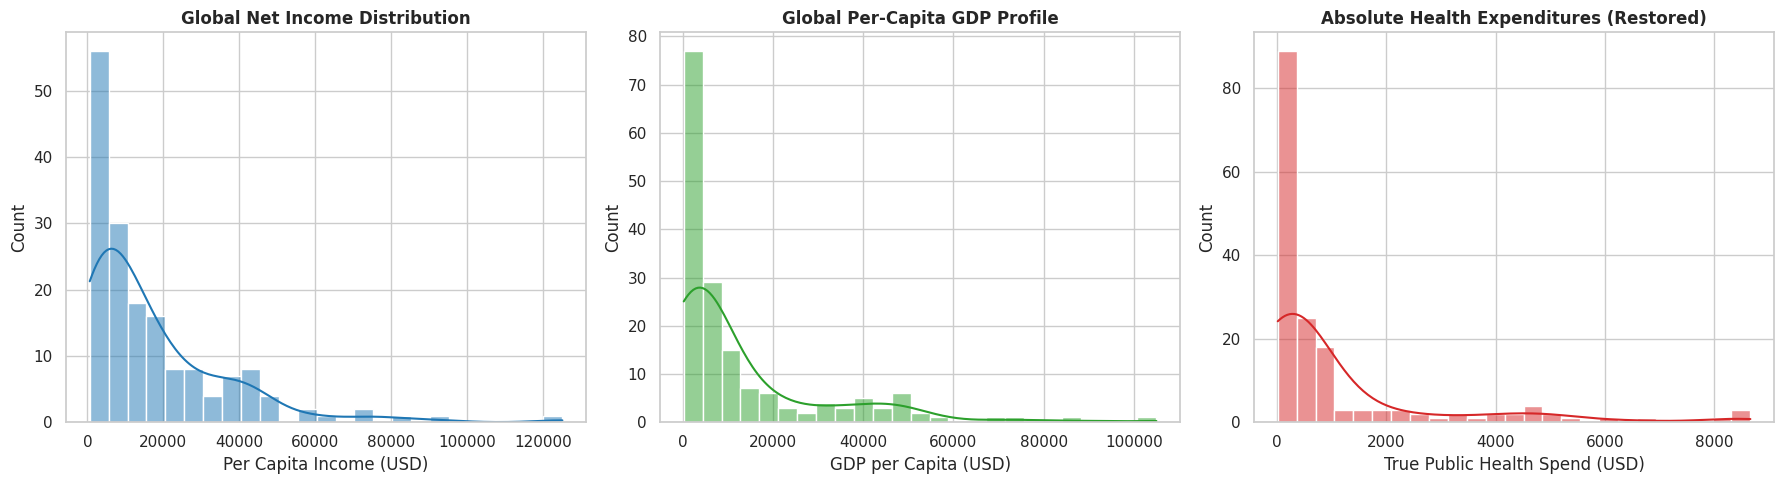

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_cleaned['income'], kde=True, color='#1f77b4', ax=axes[0], bins=25)
axes[0].set_title('Global Net Income Distribution', fontweight='bold')
axes[0].set_xlabel('Per Capita Income (USD)')

sns.histplot(df_cleaned['gdpp'], kde=True, color='#2ca02c', ax=axes[1], bins=25)
axes[1].set_title('Global Per-Capita GDP Profile', fontweight='bold')
axes[1].set_xlabel('GDP per Capita (USD)')

sns.histplot(df_cleaned['health'], kde=True, color='#d62728', ax=axes[2], bins=25)
axes[2].set_title('Absolute Health Expenditures (Restored)', fontweight='bold')
axes[2].set_xlabel('True Public Health Spend (USD)')

plt.tight_layout()
plt.savefig('socio_economic_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


sasc

In [132]:
print("K-MEANS \n")
# Configure basic math constraints
k = 3
max_iters = 150

random_indices = np.random.choice(X_scaled.shape[0], k, replace=False)
scratch_centroids = X_scaled[random_indices].copy()

for iteration in range(max_iters):
    # Measure Euclidean Distance
    distances = []
    for row in X_scaled:
        row_distances = []
        for centroid in scratch_centroids:
            # Distance formula: sqrt( sum( (x_i - mu_k)^2 ) )
            euclidean_dist = np.sqrt(np.sum((row - centroid) ** 2))
            row_distances.append(euclidean_dist)
        distances.append(row_distances)
    distances = np.array(distances)

    # Assign each country point to its nearest center index
    scratch_labels = np.argmin(distances, axis=1)
    old_centroids = scratch_centroids.copy()

    # Relocate the center positions
    for cluster_idx in range(k):
        assigned_points = X_scaled[scratch_labels == cluster_idx]
        if len(assigned_points) > 0:
            scratch_centroids[cluster_idx] = np.mean(assigned_points, axis=0)

    # Stopping iterations early if centers have stopped shifting
    centroid_shift = np.sum(np.sqrt(np.sum((old_centroids - scratch_centroids) ** 2, axis=1)))
    if centroid_shift < 1e-4:
        print(f"Convergence optimization loop finalized at iteration step: {iteration}")
        break

K-MEANS 

Convergence optimization loop finalized at iteration step: 9


In [133]:
print("\n PCA")

# Center the values around a zero-mean position
X_mean = np.mean(X_scaled, axis=0)
X_centered = X_scaled - X_mean

# Build the structural Covariance Matrix layout: (X^T * X) / (n - 1)
covariance_matrix = np.cov(X_centered.T)

# Extract the system Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort structural directions based on variance magnitude rankings
sorted_indices = np.argsort(eigenvalues)[::-1]
top_components = eigenvectors.T[sorted_indices[:2]]  # Maintain top 2 spatial directions

# Project the normalized data grid onto our new principal coordinates
X_scratch_pca = np.real(np.dot(X_centered, top_components.T))

print("\n Mathematical array vectors calculated successfully.")
print(f" Matrix Dimensions Captured: {X_scratch_pca.shape} (Countries, 2 Spatial Eigenvectors)")


 PCA

 Mathematical array vectors calculated successfully.
 Matrix Dimensions Captured: (167, 2) (Countries, 2 Spatial Eigenvectors)


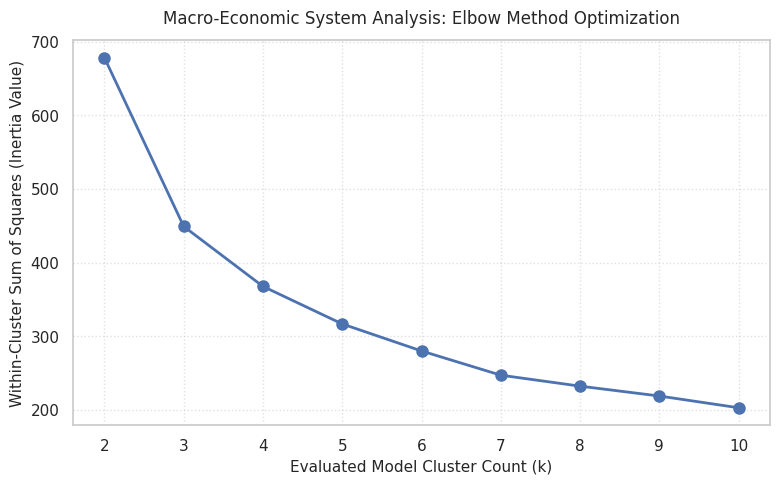

In [134]:
cluster_range = range(2, 11)
inertia_scores = []

for current_k in cluster_range:
    kmeans_evaluator = KMeans(n_clusters=current_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans_evaluator.fit(X_scaled)
    inertia_scores.append(kmeans_evaluator.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(cluster_range, inertia_scores, marker='o', linestyle='-', lw=2, markersize=8)
plt.title('Macro-Economic System Analysis: Elbow Method Optimization', fontsize=12, pad=12)
plt.xlabel('Evaluated Model Cluster Count (k)', fontsize=11)
plt.ylabel('Within-Cluster Sum of Squares (Inertia Value)', fontsize=11)
plt.xticks(cluster_range)
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('elbow_curve_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [135]:
best_k = 4
kmeans_production = KMeans(n_clusters=best_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_labels = kmeans_production.fit_predict(X_scaled)
df_cleaned['KMeans_Cluster'] = kmeans_labels

silhouette_val = silhouette_score(X_scaled, kmeans_labels)

print("             PRODUCTION K-MEANS VALIDATION INTEGRITY            ")
print(f"Set Target Cluster Allocation (k)  : {best_k}")
print(f"Captured Silhouette Quality Score  : {silhouette_val:.4f}")
print("-----------------------------------------------------------------")
print("Distribution of Segmented Countries Across Clusters:")
print(df_cleaned['KMeans_Cluster'].value_counts().sort_index())

dbscan_production = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan_production.fit_predict(X_scaled)
df_cleaned['DBSCAN_Cluster'] = dbscan_labels

print("\n" + "-"*65)
print("             COMPARATIVE DBSCAN ANALYSIS VECTOR                ")
print(f"Active Dense Density Clusters  : {len(np.unique(dbscan_labels[dbscan_labels != -1]))}")
print(f"Anomalous Noise Points Flagged : {np.sum(dbscan_labels == -1)} observations")
print("-----------------------------------------------------------------")
print("DBSCAN Group Value Counts (-1 marks isolated noise outliers):")
print(df_cleaned['DBSCAN_Cluster'].value_counts().sort_index())

             PRODUCTION K-MEANS VALIDATION INTEGRITY            
Set Target Cluster Allocation (k)  : 4
Captured Silhouette Quality Score  : 0.4117
-----------------------------------------------------------------
Distribution of Segmented Countries Across Clusters:
KMeans_Cluster
0    50
1    48
2    68
3     1
Name: count, dtype: int64

-----------------------------------------------------------------
             COMPARATIVE DBSCAN ANALYSIS VECTOR                
Active Dense Density Clusters  : 1
Anomalous Noise Points Flagged : 11 observations
-----------------------------------------------------------------
DBSCAN Group Value Counts (-1 marks isolated noise outliers):
DBSCAN_Cluster
-1     11
 0    156
Name: count, dtype: int64


In [136]:
pca_transformer = PCA(n_components=2, random_state=42)
X_pca = pca_transformer.fit_transform(X_scaled)

df_cleaned['PCA_1'] = X_pca[:, 0]
df_cleaned['PCA_2'] = np.real(X_pca[:, 1])

variance_retained = pca_transformer.explained_variance_ratio_
print(f"Variance Captured by Component 1 : {variance_retained[0]*100:.2f}%")
print(f"Variance Captured by Component 2 : {variance_retained[1]*100:.2f}%")
print(f"Total Cumulative Variance Held   : {np.sum(variance_retained)*100:.2f}%")

Variance Captured by Component 1 : 77.44%
Variance Captured by Component 2 : 10.84%
Total Cumulative Variance Held   : 88.28%


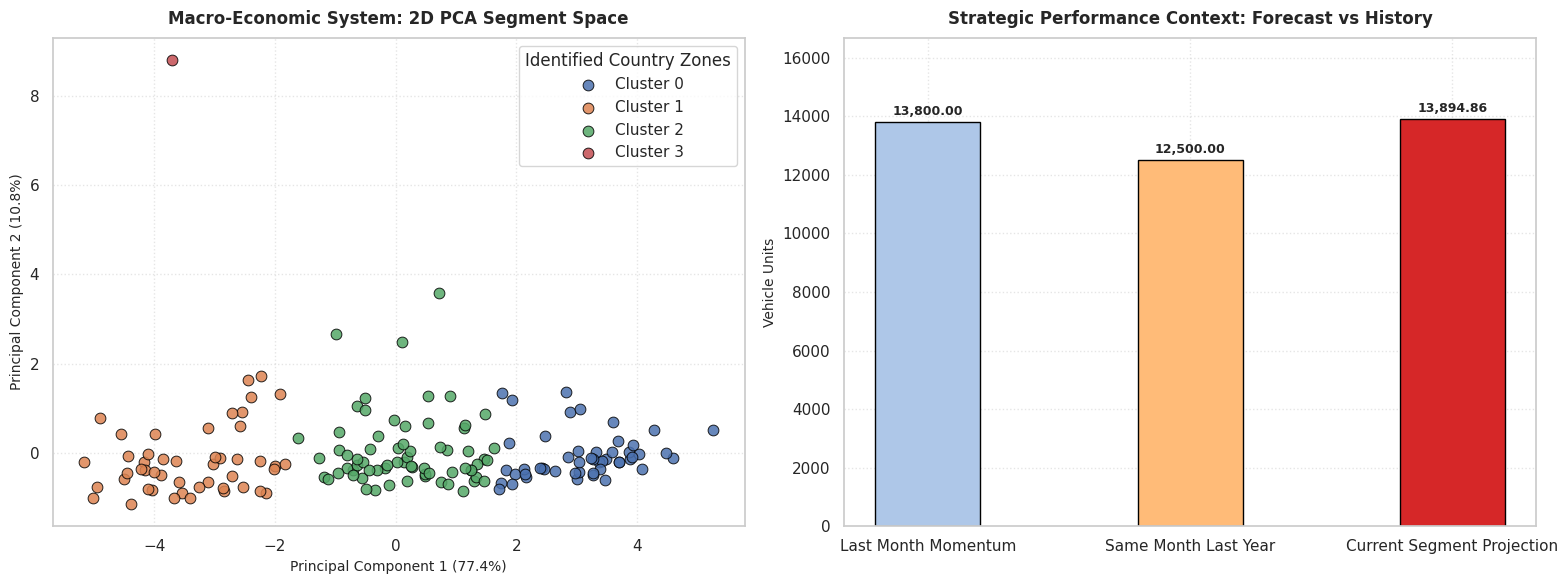

In [137]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
cluster_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}

for cluster_id in np.unique(kmeans_labels):
    cluster_mask = df_cleaned['KMeans_Cluster'] == cluster_id
    ax1.scatter(
        df_cleaned.loc[cluster_mask, 'PCA_1'],
        df_cleaned.loc[cluster_mask, 'PCA_2'],
        label=f'Cluster {cluster_id}',
        alpha=0.85, s=60, edgecolors='black', linewidth=0.7
    )

ax1.set_title('Macro-Economic System: 2D PCA Segment Space', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel(f'Principal Component 1 ({variance_retained[0]*100:.1f}%)', fontsize=10)
ax1.set_ylabel(f'Principal Component 2 ({variance_retained[1]*100:.1f}%)', fontsize=10)
ax1.legend(title='Identified Country Zones', loc='best')
ax1.grid(True, linestyle=':', alpha=0.5)

benchmarks = ['Last Month Momentum', 'Same Month Last Year', 'Current Segment Projection']
volumes = [13800.0, 12500.0, 13894.86]

bars_b = ax2.bar(benchmarks, volumes, width=0.4, color=['#aec7e8', '#ffbb78', '#d62728'], edgecolor='black')

ax2.set_title('Strategic Performance Context: Forecast vs History', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Vehicle Units', fontsize=10)
ax2.set_ylim(0, max(volumes) * 1.2)
ax2.grid(True, linestyle=':', alpha=0.5)

for bar in bars_b:
    height = bar.get_height()
    ax2.annotate(f'{height:,.2f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('macro_segmentation_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()